In [2]:
import fvtools.rivers.NVEforcing.hydapi_rivertemp as temps
import fvtools.rivers.NVEforcing.elvis_riveroutlets as elvis
import matplotlib.pyplot as plt
import cmocean as cmo

# Update the river positions and river temperatures database

# You need to download the OSM coastline and the NVE data separately
### Coastline download: https://osmdata.openstreetmap.de/data/coastlines.html
### River related downloads: https://nedlasting.nve.no/gis/
#### - "Elv -> Elvenett"
#### - "Nedbørfelt -> Nedbørsfelt til hav" 
#### - "Nedbørfelt -> Vassdragområder"
#### - "Nedbørfelt -> REGINE enhet"

In [3]:
# Identify all rivers in Norway
rivers = elvis.main(
    osm_coastline=r'./coastlines/coastlines-split-4326/lines.shp', 
    elvis = './NVE/NVEData/Elv/Elv_Elvenett.shp', 
    nedbor = './NVE/NVEData/Nedborfelt/Nedborfelt_NedborfeltTilHav.shp',
    vassdrag= './NVE/NVEData/Nedborfelt/Nedborfelt_Vassdragsomr.shp'
)

# Reset index, identify vassdragsområde and use river id as index
rivers = rivers.reset_index()
rivers['vassdragsomraade'] = rivers.rivers.apply(lambda x: int(x.split('-')[0]))
rivers = rivers.set_index('rivers')

Load the coastline
- Clip to Norway
- Project to UTM33
- Set up a KDTree for the coast

Load ELVIS
- Drop columns we won't use
- Drop rivers crossing the border
- Drop segments with unknown river ID and vassdragsnummer
- Identify which unique river each river segment is a part of
- Remove duplicate data about each river, find the river outlet


In [ ]:
# Dump the river positions
rivers.to_csv('riverdata/river_positions.csv')

# Download river temperatures from hydapi

In [3]:
# Download observed temperatures, create a river temperature climatology for the water sheds
observations, climatology = temps.main(rivers, api_key = 'mykey', max_distance_to_ocean = 5000, max_meters_over_sealevel = 50)

Read available stations from hydapi
- found 175 stations

Figure out which river connects to the stations
- Found stations recording water temperature at 175 unique rivers.
- Filtered out 33 due to distance to the coastline

Download data from 85 stations
- Found data at 29 stations, 56 stations were empty or not quality controlled.

Process temperature data
- Removing erroneous spikes (values > 30 C) and running a filter to remove noise
- Create a full climatology for the entire coast based on filtered temperatures


In [4]:
# Dump the observed tempeatures
for nve_location in observations:
    observations[nve_location].to_csv(f'riverdata/temperature_observations/{nve_location}.csv')

# Dump the watershed climatologies
climatology.to_csv('riverdata/temperature_climatology.csv')

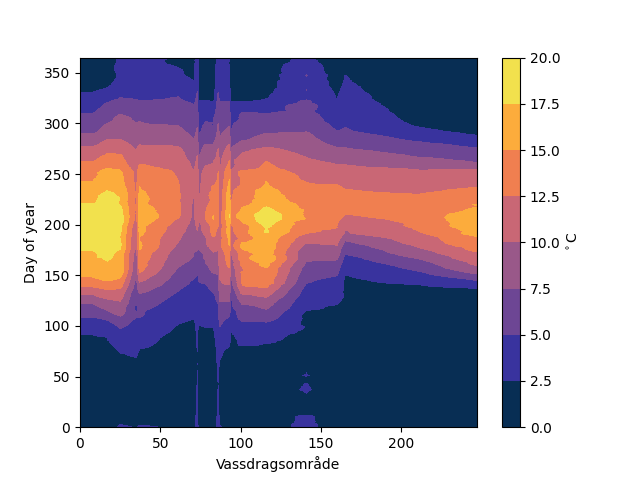

In [5]:
%matplotlib widget
plt.figure()
c = plt.contourf(climatology.T, cmap = cmo.cm.thermal)
plt.colorbar(c, label = r'$^\circ$C')
plt.xlabel('Vassdragsområde')
plt.ylabel('Day of year')
plt.show()